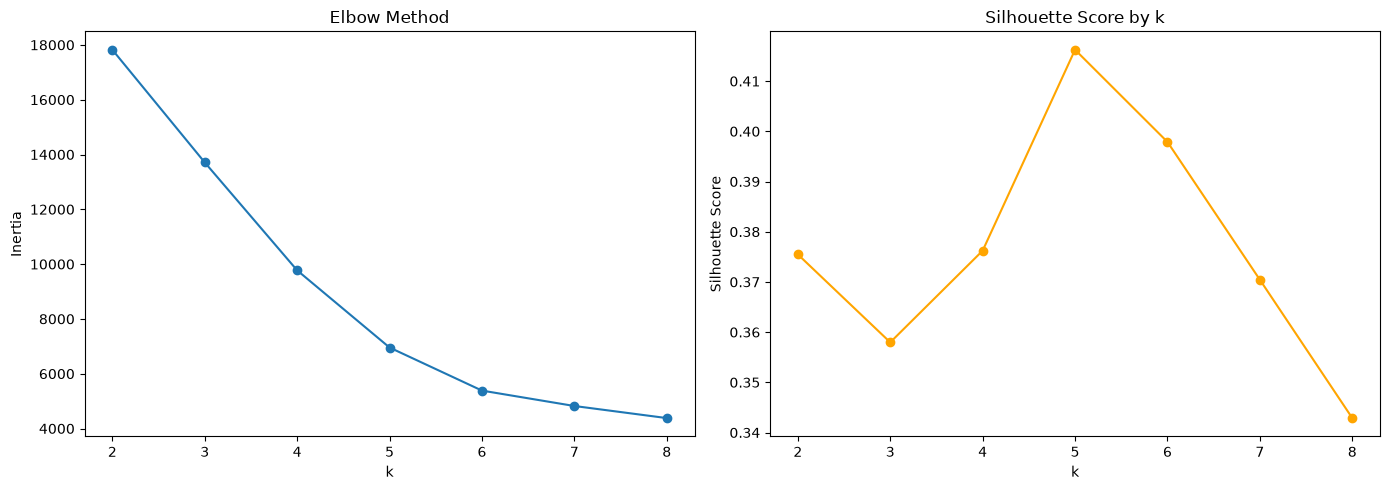

In [1]:
import sys
sys.path.append('../src')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

df = pd.read_csv("../data/processed/synthetic_viewing_behavior.csv")

features = ['avg_sessions_per_week', 'avg_completion_rate', 'days_since_last_watch', 'genre_diversity', 'tenure_days']
X = df[features]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

inertias = []
sil_scores = []
k_range = range(2, 9)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(X_scaled, labels))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(list(k_range), inertias, marker='o')
axes[0].set_xlabel('k')
axes[0].set_ylabel('Inertia')
axes[0].set_title('Elbow Method')

axes[1].plot(list(k_range), sil_scores, marker='o', color='orange')
axes[1].set_xlabel('k')
axes[1].set_ylabel('Silhouette Score')
axes[1].set_title('Silhouette Score by k')

plt.tight_layout()
plt.show()

### Choosing k

The elbow method shows a gradually flattening curve without a single sharp 
bend, making it ambiguous on its own (k=4, 5, or 6 are all plausible by eye). 
The silhouette score resolves this: it peaks distinctly at k=5 (0.416), 
outperforming both k=4 (0.376) and k=6 (0.398). We proceed with k=5.

In [2]:
final_k = 5
kmeans = KMeans(n_clusters=final_k, random_state=42, n_init=10)
df['cluster'] = kmeans.fit_predict(X_scaled)

cluster_profile = df.groupby('cluster')[features].mean().round(2)
cluster_profile['size'] = df['cluster'].value_counts().sort_index()
print(cluster_profile)

print()
print(pd.crosstab(df['cluster'], df['persona']))

         avg_sessions_per_week  avg_completion_rate  days_since_last_watch  \
cluster                                                                      
0                         1.47                 0.52                   0.96   
1                         6.67                 0.64                   0.70   
2                         0.00                 0.00                  90.00   
3                         4.44                 0.30                   4.24   
4                        20.02                 0.85                   0.06   

         genre_diversity  tenure_days  size  
cluster                                      
0                  11.09        28.50   533  
1                   5.83       413.73  2440  
2                  11.00         2.12    17  
3                   5.45       282.02   985  
4                   6.46       465.05  1025  

persona  casual_viewer  churning_user  new_user  power_binger  weekend_watcher
cluster                                            

### Cluster Interpretation vs Ground Truth Personas

K-Means with k=5 recovered Power Bingers and Churning Users almost perfectly 
(100% and 99.7% purity respectively), and isolated a small, meaningful edge 
case of zero activity new sign ups (n=17). However, it merged Casual Viewers 
and Weekend Watchers into a single cluster (n=2440) rather than separating 
them.

This is expected, not a failure: these two personas were designed to differ 
mainly in genre preference and day of week timing, neither of which was 
included as a clustering feature. This demonstrates a core principle of 
unsupervised learning , K Means finds structure only along the dimensions 
you give it. The resulting segments are relabeled below based on their 
actual behavioral profile, not forced to match the original persona design.

In [3]:
cluster_names = {
    4: 'Power Bingers',
    3: 'Churning Users',
    1: 'Steady Regulars',
    0: 'Exploratory New Users',
    2: 'Dormant Sign-ups',
}
df['segment'] = df['cluster'].map(cluster_names)

In [4]:
df.to_csv("../data/processed/user_segments.csv", index=False)